In [1]:
import datetime
import importlib
import os
import sys
# Ignore Warning
import warnings

import contextily as ctx
import dask.dataframe as dd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [2]:
def reload_package(package):
    for module in list(sys.modules.keys()):
        if module.startswith(package.__name__):
            importlib.reload(sys.modules[module])

In [3]:
import moveminer2
from moveminer2.core.trajectory import Trajectory
from moveminer2.utils.config import col_names

reload_package(moveminer2)
analyzer = moveminer2.Analyzer()
# Visualizer
kde_plot = analyzer.kde_plot
spatial_plot = analyzer.spatial_plot
heatmap_plot = analyzer.heatmap_plot
polar_plot = analyzer.polar_plot
# Metrics
distance_calculator = analyzer.metrics.distance_calculator
timediff_calculator = analyzer.metrics.timediff_calculator
speed_calculator = analyzer.metrics.speed_calculator
radius_calculator = analyzer.metrics.radius_calculator
turning_angle_calculator = analyzer.metrics.turning_angle_calculator
od_matrix_calculator = analyzer.metrics.od_matrix_calculator
# Preprocessing
stop_detector = analyzer.preprocessing.stop_detector
outlier_detector = analyzer.preprocessing.outlier_detector
cluster_detector_kmeans = analyzer.preprocessing.cluster_detector
cluster_detector_dbscan = analyzer.pattern_mining.cluster_detector
compressor = analyzer.preprocessing.compressor
segmenter = analyzer.preprocessing.segmenter

### Setup

In [4]:
def load_lake_eola(path: str) -> pd.DataFrame:
    dataset = dd.read_csv(path, sep=",", usecols=["id", "x", "y", "datetime"])
    dataset[col_names.TRAJECTORY_ID] = dataset["id"]
    dataset["t"] = dd.to_datetime(dataset["datetime"])
    return dataset.compute()

In [5]:
# Load datasets
lake_eola = load_lake_eola("./datasets/lake_eola_park.csv")

In [6]:
lake_eola_title = "Lake Eola Park"
lake_eola_mt = Trajectory(lake_eola)

In [7]:
output_folder = "./assets/MoveMiner"

### Reduce Uncertainty (Fill Gaps)

In [30]:
traj_0 = lake_eola_mt[lake_eola_mt[col_names.TRAJECTORY_ID] == lake_eola_mt[col_names.TRAJECTORY_ID].unique()[0]]

In [17]:
def plot_calibration(df, category, output_dir):
    # Criar GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.x, df.y), crs="EPSG:4326"
    )
    gdf = gdf.to_crs(
        epsg=3857
    )  # Projeção para mapas da Web (compatível com contextily)

    # Obtém os limites do GeoDataFrame (em EPSG:3857)
    bbox = gdf.total_bounds  # [minx, miny, maxx, maxy]

    # Calcula a margem (5% do tamanho em cada eixo)

    margin_x = (bbox[2] - bbox[0]) * 0.05
    margin_y = (bbox[3] - bbox[1]) * 0.05

    # Aplica a margem aos limites
    minx = bbox[0] - margin_x
    maxx = bbox[2] + margin_x
    miny = bbox[1] - margin_y
    maxy = bbox[3] + margin_y

    # Adjusting subplot dimensions and stretching images
    fig, ax = plt.subplots()  # Define ax with a figure and axis
    if not gdf.empty:
        if category is not None and category in gdf.columns:
            gdf.plot(
                column=category,
                ax=ax,  # Pass ax to the plot
                legend=True,  # Add legend for the category
                cmap=plt.cm.colors.ListedColormap(["#ff7f0e", "#1f77b4"])  # Use the specified color palette
            )

        else:
            gdf.plot(ax=ax)  # Pass ax to the plot
    else:
        gdf.plot(ax=ax)  # Pass ax to the plot
    
    ax.axis("off")
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    # ax.set_aspect("auto")  # Stretch images to fill subplot space

    # Adicionar background
    try:
        ctx.add_basemap(
            ax,
            crs=gdf.crs.to_string(),
            attribution=""
        )
    except (ValueError, KeyError, TypeError):
        pass  # caso não haja pontos nessa hora

 
    # Verifica se a pasta de saída existe, se não, cria
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Salva o arquivo
    plt.savefig(
        f"{output_dir}/{category}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{output_dir}/{category}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [20]:
def plot_smoother(df1, df2, category, output_dir):
    # Criar GeoDataFrames
    gdf1 = gpd.GeoDataFrame(
        df1, geometry=gpd.points_from_xy(df1.x, df1.y), crs="EPSG:4326"
    ).to_crs(epsg=3857)
    gdf2 = gpd.GeoDataFrame(
        df2, geometry=gpd.points_from_xy(df2.x, df2.y), crs="EPSG:4326"
    ).to_crs(epsg=3857)

    # Obtém os limites combinados
    bbox = np.concatenate([gdf1.total_bounds.reshape(2,2), gdf2.total_bounds.reshape(2,2)], axis=0)
    minx, miny = bbox[:,0].min(), bbox[:,1].min()
    maxx, maxy = bbox[:,0].max(), bbox[:,1].max()
    margin_x = (maxx - minx) * 0.05
    margin_y = (maxy - miny) * 0.05
    minx -= margin_x
    maxx += margin_x
    miny -= margin_y
    maxy += margin_y

    fig, ax = plt.subplots()
    if not gdf1.empty:
        gdf1.plot(ax=ax, color="#1f77b4", label="Original")
    if not gdf2.empty:
        gdf2.plot(ax=ax, color="#ff7f0e", label="Smoother")
    ax.legend()
    ax.axis("off")
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    try:
        ctx.add_basemap(ax, crs=gdf1.crs.to_string(), attribution="")
    except (ValueError, KeyError, TypeError):
        pass

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(
        f"{output_dir}/{category}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{output_dir}/{category}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


In [11]:
traj_0['Calibration'] = np.where(traj_0['t'].dt.second % 5 == 0, 'Original 5Hz', 'Calibration 1Hz')

In [12]:
traj_0_compressed = traj_0[traj_0['Calibration'] == 'Original 5Hz']

In [13]:
def calibration(df, n=1):
    # Create a copy of the DataFrame to avoid modifying the original
    traj_0_compressed_with_midpoints = traj_0_compressed.copy()

    # Iterate through the rows and calculate the midpoints
    rows = []
    for i in range(len(traj_0_compressed) - 1):
        current_row = traj_0_compressed.iloc[i]
        next_row = traj_0_compressed.iloc[i + 1]
        
        # Calculate the first midpoint
        for j in range(1, n + 1):
            midpoint = {
            'x': current_row['x'] + j * (next_row['x'] - current_row['x']) / (n + 1),
            'y': current_row['y'] + j * (next_row['y'] - current_row['y']) / (n + 1),
            't': current_row['t'] + j * (next_row['t'] - current_row['t']) / (n + 1),
            'id': current_row['id'],
            'trajectory_id': current_row['trajectory_id'],
            'Calibration': 'Calibration 1Hz'
            }
            rows.append(midpoint)
    # Append the new rows to the DataFrame
    midpoints_df = pd.DataFrame(rows)
    return pd.concat([traj_0_compressed_with_midpoints, midpoints_df]).sort_values(by='t').reset_index(drop=True)

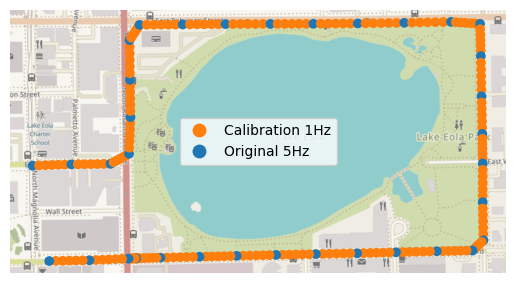

In [18]:
plot_calibration(calibration(traj_0_compressed, 5), 'Calibration'  , "./assets\MoveMiner/Uncertainty Module/")

### Smoothing

In [28]:
from scipy import signal
from shapely import Point
def smoother(trj, w: int = None, p: int = 3):
    trj = trj.copy()
    if w is None:
        w = p + 3 - p % 2
    if w % 2 != 1:
        raise Exception(f"Invalid smoothing parameter w ({w}): n must be odd")
    trj['x'] = signal.savgol_filter(
        trj['x'], window_length=w, polyorder=p, axis=0
    )
    trj['y'] = signal.savgol_filter(
        trj['y'], window_length=w, polyorder=p, axis=0
    )
    return trj


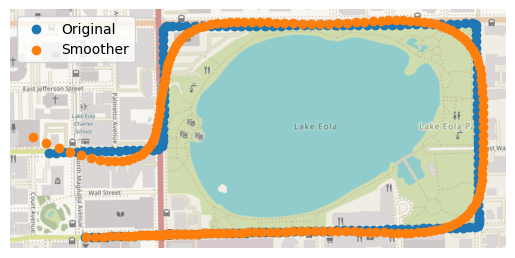

In [31]:
plot_smoother(
    traj_0,
    smoother(traj_0, 49),
    "Smoother",
    "./assets/MoveMiner/Uncertainty Module/",
)